# Detection Spam Emails

Spam messages are unsolicited or unwanted emails/messages sent in bulk to users. Detecting spam emails automatically helps prevent unnecessary clutter in users' inboxes.

In this article, we will build a spam email detection model that classifies emails as **Spam** or **Ham (Not Spam)** using TensorFlow, one of the most popular deep learning libraries.

# Step 1: Import the Required Libraries 


#### Before we begin let’s import the necessary libraries: pandas, numpy, tensorflow, matplotlib, wordcloud, nltk for data processing, model building, and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\cucum\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Step 2: Load the Dataset
#### We’ll use a dataset containing labeled emails (Spam or Ham). Let’s load the dataset and inspect its structure. 

In [2]:
data = pd.read_csv(r'C:\Users\cucum\Downloads\dataset.csv\spam_ham_dataset.csv') 
data.head() 

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [3]:
data.shape

(5171, 4)

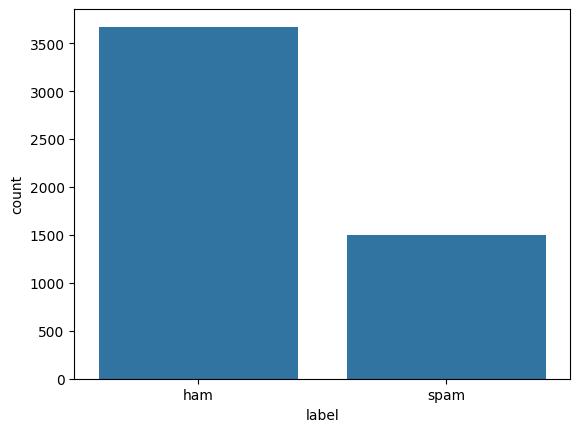

In [4]:
sns.countplot(x='label', data=data) 
plt.show()

# Step 3: Balance the Dataset
#### We can clearly see that number of samples of Ham is much more than that of Spam which implies that the dataset we are using is imbalanced. To address the imbalance we’ll downsample the majority class (Ham) to match the minority class (Spam).

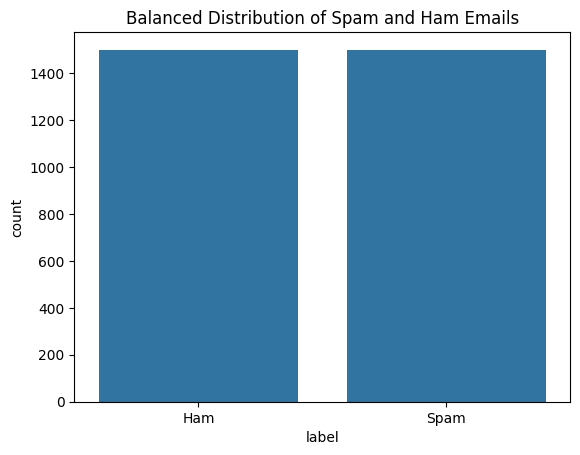

In [5]:
ham_msg = data[data['label'] == 'ham'] 
spam_msg = data[data['label'] == 'spam'] 

# Downsample Ham emails to match the number of Spam emails
ham_msg_balanced = ham_msg.sample(n=len(spam_msg), random_state=42) 

# Combine balanced data
balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True) 

# Visualize the balanced dataset
sns.countplot(x='label', data=balanced_data) 
plt.title("Balanced Distribution of Spam and Ham Emails") 
plt.xticks(ticks=[0,1], labels=['Ham', 'Spam']) 
plt.show()


# Step 4: Clean the Text
#### Textual data often requires preprocessing before feeding it into a machine learning model. Common steps include removing stopwords, punctuations, and performing stemming/lemmatization.

#### We’ll perform the following steps:

##### - Stopwords Removal
##### - Punctuations Removal
##### - Stemming or Lemmatization
####  Although removing data means loss of information we need to do this to make the data perfect to feed into a machine learning model.

In [6]:
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '') 
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


In [7]:
punctuation = string.punctuation 
def remove_punctuation(text): 
    temp = str.maketrans('', '', punctuation) 
    return text.translate(temp) 

balanced_data['text'] = balanced_data['text'].apply(remove_punctuation) 
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


In [8]:
def remove_stopwords(text): 
    stop_words = stopwords.words('english') 

    imp_words = [] 

    for word in text.split(): 
        word = word.lower() 

        if word not in stop_words: 
            imp_words.append(word) 

    output = ' ' . join(imp_words) 

    return output 

balanced_data['text'] = balanced_data['text'].apply(lambda text: remove_stopwords(text)) 
balanced_data.head()


,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


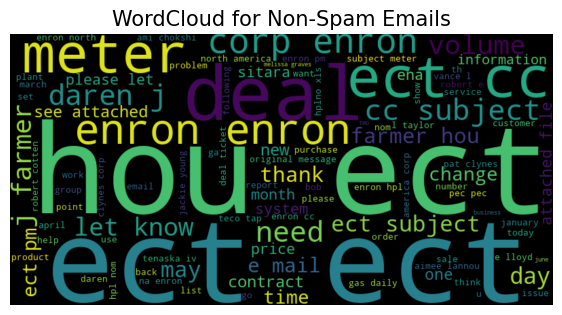

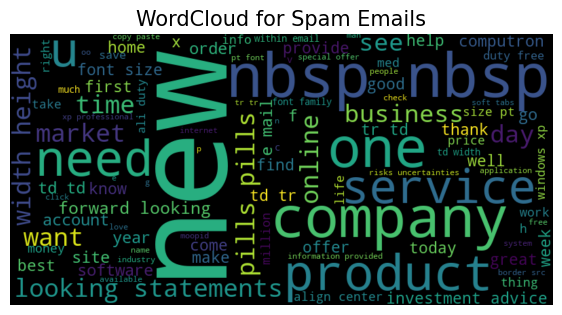

In [9]:
def plot_word_cloud(data, typ):
    email_corpus = " ".join(data['text'])
    wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(email_corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()

plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ='Non-Spam')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ='Spam')

# Step 6: Tokenization and Padding
#### Machine learning models work with numbers, so we need to convert the text data into numerical vectors using Tokenization and Padding.

#### Tokenization: Converts each word into a unique integer.
#### Padding: Ensures that all text sequences have the same length, making them compatible with the model.

In [10]:
train_x, test_x, train_y, test_y = train_test_split(
    balanced_data['text'], balanced_data['label'], test_size=0.2, random_state=42
)

tokenizer = Tokenizer(num_words=5000) 
tokenizer.fit_on_texts(train_x) 

train_sequences = tokenizer.texts_to_sequences(train_x) 
test_sequences = tokenizer.texts_to_sequences(test_x)  

max_len = 100  
train_sequence = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post') 
test_sequence = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post') 

train_y = (train_y == 'spam').astype(int) 
test_y = (test_y == 'spam').astype(int)

# Step 7: Define the Model
#### We will build a deep learning model using a Sequential architecture. This model will include:

##### - Embedding Layer: Learns vector representations of words.
##### - LSTM Layer: Captures patterns in sequences.
##### - Fully Connected Layer: Extracts relevant features.
##### - Output Layer: Predicts whether an email is spam or not

In [11]:
model = tf.keras.Sequential([ 
    tf.keras.layers.Embedding(input_dim=5000, output_dim=64, input_length=max_len),  
    tf.keras.layers.LSTM(16), 
    tf.keras.layers.Dense(32, activation='relu'),  
    tf.keras.layers.Dense(1, activation='sigmoid')
    ])  

model.compile(  
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),   
    optimizer='adam',
    metrics=['accuracy'] 
    )

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Step 8: Train the Model
#### We train the model using EarlyStopping and ReduceLROnPlateau callbacks. These callbacks help stop the training early if the model’s performance doesn’t improve and reduce the learning rate to fine-tune the model.

In [12]:
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_sequence, train_y,
    validation_data=(test_sequence, test_y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5759 - loss: 0.6732 - val_accuracy: 0.8183 - val_loss: 0.5246 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9291 - loss: 0.2610 - val_accuracy: 0.9550 - val_loss: 0.1633 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9566 - loss: 0.1660 - val_accuracy: 0.9417 - val_loss: 0.1905 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9595 - loss: 0.1531 - val_accuracy: 0.9600 - val_loss: 0.1548 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9637 - loss: 0.1552 - val_accuracy: 0.9667 - val_loss: 0.1484 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9666 - loss: 0.1423 - val_accuracy: 0.9650 - val_loss: 0.1426 - learning_rate: 0.0010
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9712 - loss: 0.1263 - val_acc

In [15]:
test_loss, test_accuracy = model.evaluate(test_sequence, test_y)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9667 - loss: 0.1484
Test Loss : 0.14844726026058197
Test Accuracy : 0.9666666388511658


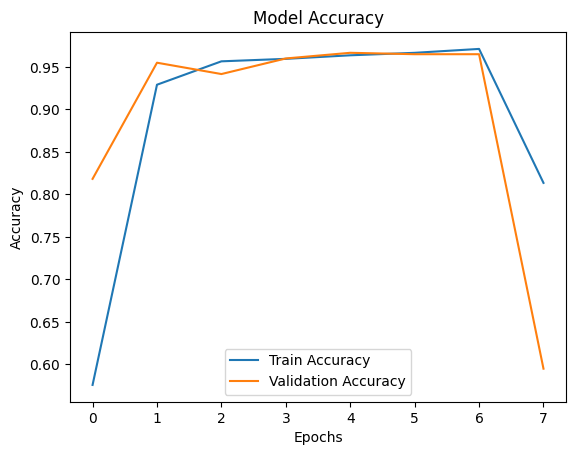

In [14]:
plt.plot(history.history['accuracy'], label='Train Accuracy') 
plt.plot(history.history['val_accuracy'], label='Validation Accuracy') 
plt.title('Model Accuracy') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
plt.legend() 
plt.show()